# Project Ideas

## Ideas talked about:
- Ideal concert conditions
- Ideal beach day conditions

## Initial thoughts:

We have decided to go with the ideal beach day conditions. Potential variables include:
- heat/cold
- humidity
- UV (cloud coverage?)
- water temperature
- rip currents
- tides
- rain/storms
- wind
- wave height
- water conditions (ex. algae blooms?)

We are likely going to focus on the East Coast and the Gulf for this project. 

## Why is this interesting?

This topic gives us the opportunity to explore what most people would consider comfortable or ideal conditions to go to the beach. We can further explore what conditons might be too extreme for the human body and what might just generally be deemed good/bad beach conditions. It will also be interesting to see the way conditions differ across the map. For example, conditions might be ideal in Florida but not in Maine.

## Why might this be useful?

Creating maps that show extremities could be useful when communicating with the public. Maps of things like extreme temperatures might discourage some people from heading to the beach and get them to stay indoors, which can reduce the risk of things like heat stroke. It's not just about keeping everyone comfortable, it's also about keeping making sure people understand what types of conditions could be potentially dangerous.

# Choosing our data

We looked for model runs that had both good and bad weather. We settled on a time frame that had good weather to start, saw Tropical Storm/Tropical Depression Chantal move up the East Coast, and then alternated between days with rain and sun.

## Model runs
- Start July 1st 00Z
- Go through July 11th 00Z

## Variable names

Data:

array(['PRMSL', 'CLMR', 'ICMR', 'RWMR', 'SNMR', 'GRLE', 'REFD', 'REFC',
       'VIS', 'UGRD', 'VGRD', 'VRATE', 'GUST', 'HGT', 'TMP', 'RH', 'SPFH',
       'VVEL', 'DZDT', 'ABSV', 'O3MR', 'TCDC', 'HINDEX', 'MSLET', 'PRES',
       'TSOIL', 'SOILW', 'SOILL', 'CNWAT', 'WEASD', 'SNOD', 'PEVPR',
       'ICETK', 'DPT', 'APTMP', 'TMAX', 'TMIN', 'ICEG', 'CPOFP', 'CPRAT',
       'PRATE', 'APCP', 'ACPCP', 'WATR', 'CSNOW', 'CICEP', 'CFRZR',
       'CRAIN', 'LHTFL', 'SHTFL', 'GFLUX', 'UFLX', 'VFLX', 'SFCR',
       'FRICV', 'U-GWD', 'V-GWD', 'VEG', 'SOTYP', 'WILT', 'FLDCP',
       'SUNSD', 'LFTX', 'CAPE', 'CIN', 'PWAT', 'CWAT', 'TOZNE', 'LCDC',
       'MCDC', 'HCDC', 'CWORK', 'DSWRF', 'DLWRF', 'USWRF', 'ULWRF',
       'HLCY', 'USTM', 'VSTM', 'ICAHT', 'VWSH', '4LFTX', 'HPBL', 'POT',
       'PLPL', 'LAND', 'ICEC', 'ALBDO', 'ICETMP'], dtype=object)

Variables we will use and what they mean:
| Variable Name | Meaning |
| ------------- | ------- |
| UGRD | u-component of the wind |
| VGRD | v-component of the wind |
| TMP | temperature |
| TCDC | total cloud cover |
| DPT | dewpoint temperature |
| APCP | total precipitation |


- UGRD and VGRD will be used to calculate the wind speed (no wind to a light breeze would make for ideal beach conditions).
- TMP will be used to get the temperature (temperatures that are warm but not too hot would be an ideal beach day).
- TCDC will be used to get cloud cover data (want more sun for ideal beach day).
- DPT will be used to get the dewpoint temperature (want dewpoints that aren't too high or too low for comfortable beach conditions).
- APCP will be used to get precipitation data (less precipitation means better beach day).

In [1]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
run = pd.Timestamp("2025-07-01-00")

In [3]:
H = Herbie(run, model="gfs", fxx=6, save_dir='./data/', overwrite=True)

✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2025-Jul-01 00:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ aws


In [4]:
table = H.inventory()

In [5]:
table.variable.unique()

array(['PRMSL', 'CLMR', 'ICMR', 'RWMR', 'SNMR', 'GRLE', 'REFD', 'REFC',
       'VIS', 'UGRD', 'VGRD', 'VRATE', 'GUST', 'HGT', 'TMP', 'RH', 'SPFH',
       'VVEL', 'DZDT', 'ABSV', 'O3MR', 'TCDC', 'HINDEX', 'MSLET', 'PRES',
       'TSOIL', 'SOILW', 'SOILL', 'CNWAT', 'WEASD', 'SNOD', 'PEVPR',
       'ICETK', 'DPT', 'APTMP', 'TMAX', 'TMIN', 'ICEG', 'CPOFP', 'CPRAT',
       'PRATE', 'APCP', 'ACPCP', 'WATR', 'CSNOW', 'CICEP', 'CFRZR',
       'CRAIN', 'LHTFL', 'SHTFL', 'GFLUX', 'UFLX', 'VFLX', 'SFCR',
       'FRICV', 'U-GWD', 'V-GWD', 'VEG', 'SOTYP', 'WILT', 'FLDCP',
       'SUNSD', 'LFTX', 'CAPE', 'CIN', 'PWAT', 'CWAT', 'TOZNE', 'LCDC',
       'MCDC', 'HCDC', 'CWORK', 'DSWRF', 'DLWRF', 'USWRF', 'ULWRF',
       'HLCY', 'USTM', 'VSTM', 'ICAHT', 'VWSH', '4LFTX', 'HPBL', 'POT',
       'PLPL', 'LAND', 'ICEC', 'ALBDO', 'ICETMP'], dtype=object)

# Figuring Out Our Maps

## Latitude and Longitude

- latitude: 25 to 50
- longitude: -100 to -60

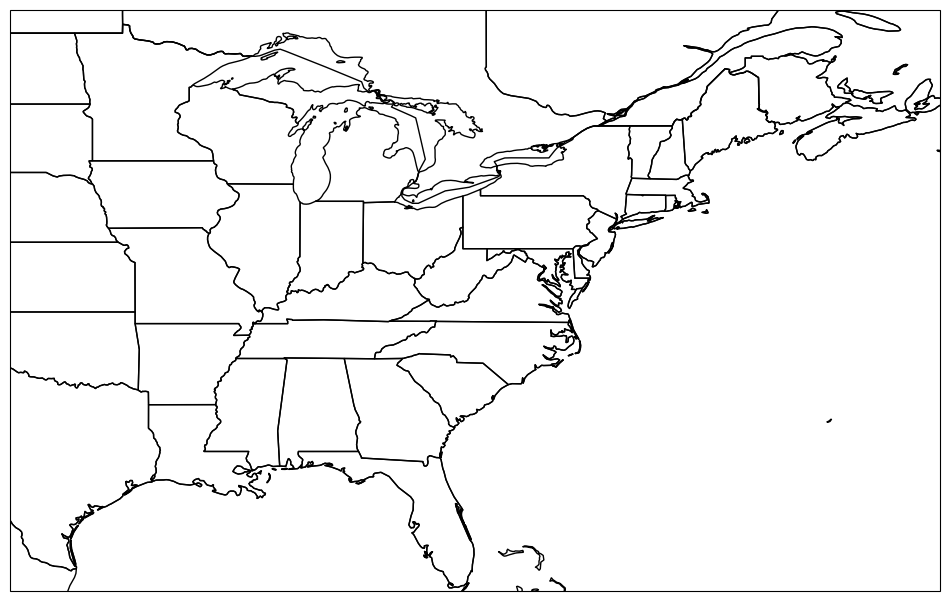

In [6]:
#Test map
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

# Coding the Maps

In [9]:
#Open dataset
ds = xr.open_dataset("beachday.nc")

FileNotFoundError: [Errno 2] No such file or directory: '/courses/meteo473/sp26/473_sp26_group3/MS1 Work/beachday.nc'

In [ ]:
#Print dataset
ds

In [8]:
#Choose forecast hour
ds_time = ds.isel(valid_time=5)

NameError: name 'ds' is not defined

In [11]:
#Define function for base maps
def base_map():
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)
    return fig, ax

Text(1.0, 1.0, 'Init: 12Z Tue Jul 01 2025\n Valid: 18Z Wed Jul 02 2025')

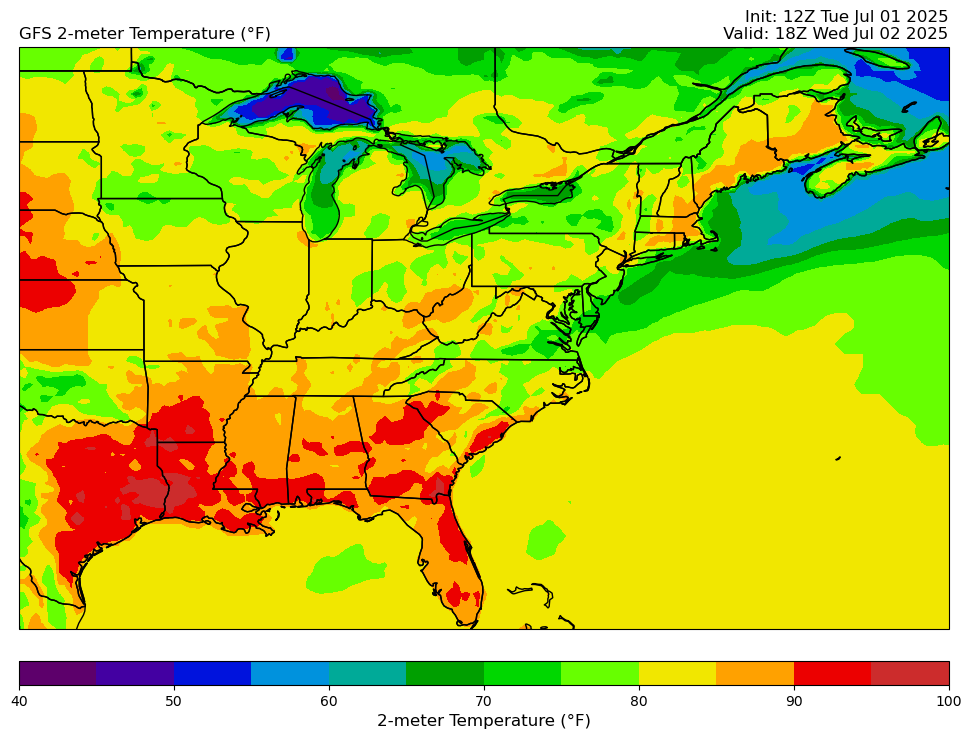

In [12]:
#Temperature map
temp_F = (ds_time['t2m'] - 273.15) * (9/5) + 32
temp_levels = np.arange(40, 105, 5)
fig, ax = base_map()
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.07, pos.width, 0.03])     #Align colorbar with map
contour_temp = ax.contourf(ds_time['longitude'], ds_time['latitude'], temp_F, levels=temp_levels, cmap='nipy_spectral', transform=ccrs.PlateCarree())
temp_color_bar = plt.colorbar(contour_temp, cax=cbar_ax, orientation='horizontal', pad=0.05)
temp_color_bar.set_label('2-meter Temperature (°F)', fontsize=12)
init_time = pd.to_datetime(ds.valid_time.values[0]).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.valid_time.values).strftime('%HZ %a %b %d %Y')
ax.set_title('GFS 2-meter Temperature (°F)', loc='left', fontsize=12)
ax.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=12)

In [3]:
#Dewpoint map
dewpoint= ds_time['d2m']
dewpoint_F = (ds_time['d2m'] - 273.15) * (9/5) + 32
dewpoint_levels = np.arange(30, 85, 5)
fig, ax = base_map()
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.07, pos.width, 0.03])     #Align colorbar with map
contour_dewpoint = ax.contourf(ds_time['longitude'], ds_time['latitude'], dewpoint_F, levels=dewpoint_levels, cmap='BrBG', transform=ccrs.PlateCarree())
dewpoint_color_bar = plt.colorbar(contour_dewpoint, cax=cbar_ax, orientation='horizontal', pad=0.05)
dewpoint_color_bar.set_label('2-meter Dewpoint Temperature (°F)', fontsize=12)
init_time = pd.to_datetime(ds.valid_time.values[0]).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.valid_time.values).strftime('%HZ %a %b %d %Y')
ax.set_title('GFS 2-meter Dewpoint Temperature Temperature (°F)', loc='left', fontsize=12)
ax.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=12)

NameError: name 'ds_time' is not defined

Text(1.0, 1.0, 'Init: 12Z Tue Jul 01 2025\n Valid: 18Z Wed Jul 02 2025')

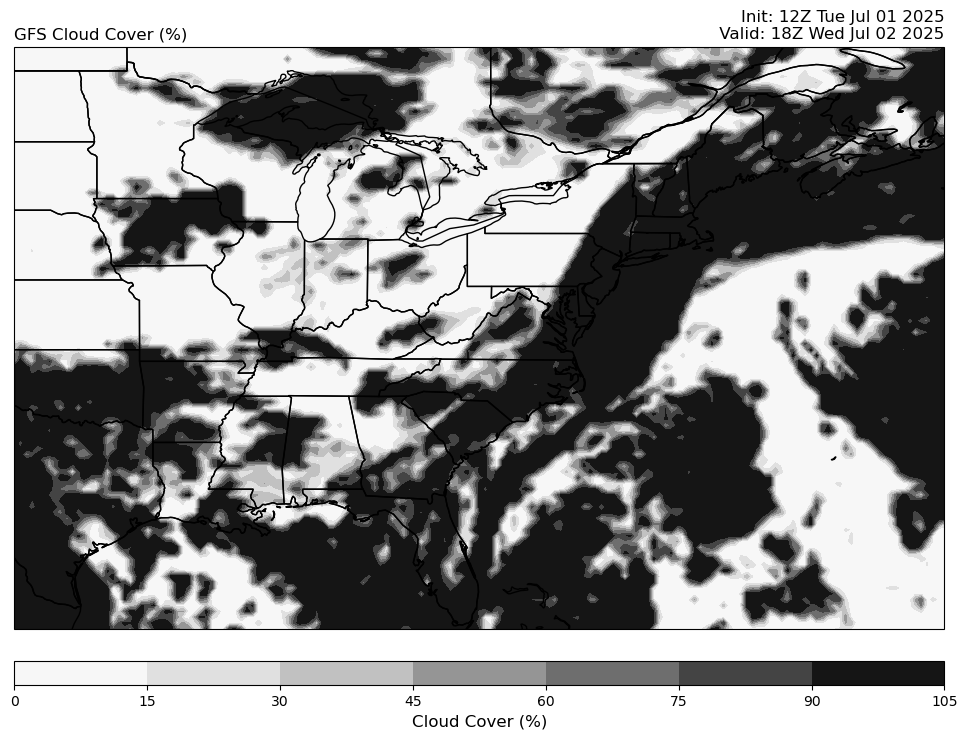

In [22]:
#Cloud cover map
cloud_levels = np.arange(0, 100, 5)
fig, ax = base_map()
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.07, pos.width, 0.03])     #Align colorbar with map
contour_clouds = ax.contourf(ds_time['longitude'], ds_time['latitude'], ds_time['tcc'], cmap='Greys', transform=ccrs.PlateCarree())
cloud_color_bar = plt.colorbar(contour_clouds, cax=cbar_ax, orientation='horizontal', pad=0.05)
cloud_color_bar.set_label('Cloud Cover (%)', fontsize=12)
init_time = pd.to_datetime(ds.valid_time.values[0]).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.valid_time.values).strftime('%HZ %a %b %d %Y')
ax.set_title('GFS Cloud Cover (%)', loc='left', fontsize=12)
ax.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=12)

Text(1.0, 1.0, 'Init: 12Z Tue Jul 01 2025\n Valid: 18Z Wed Jul 02 2025')

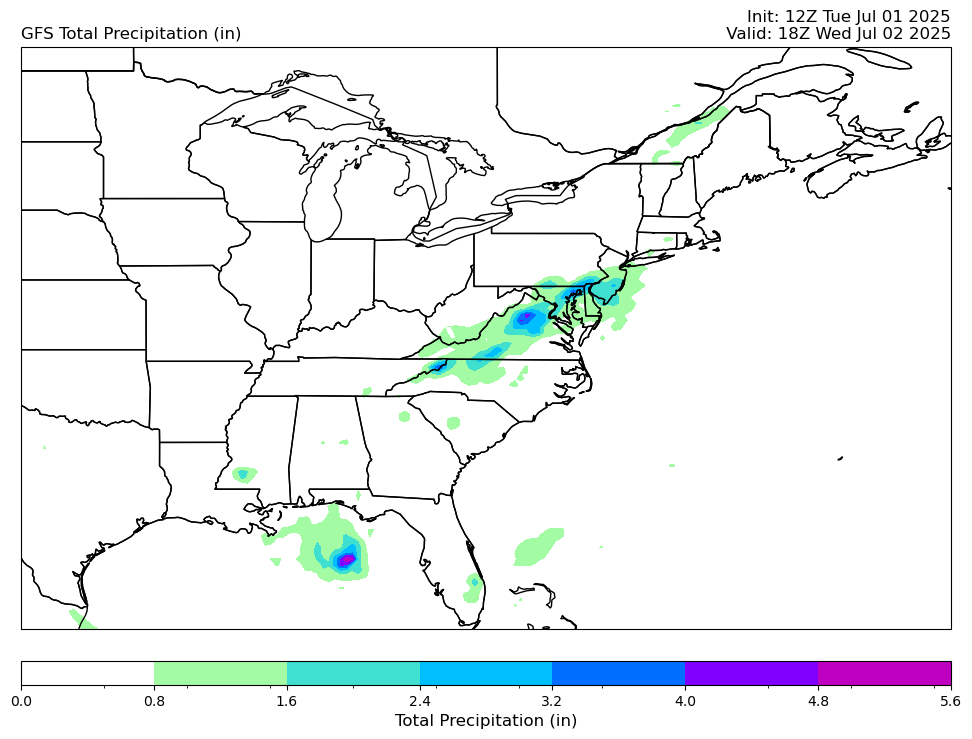

In [38]:
#Total precipitation map
tp_mm = ds_time['tp']
tp_in = tp_mm / 25.4
tp_colors = [
    "#ffffff",
    "#c1ffc1",
    "#a3fca3",
    "#80f280",
    "#40e0d0",
    "#00bfff",
    "#009fff",
    "#006fff",
    "#8000ff",
    "#a000e0",
    "#c000c0",
    "#d10d98",
    "#e000a0",
    "#ff0080",
    "#ff4500",
    "#ff8c00",
    "#ffc800",
    "#e0e000",
    "#ffff00",
]
tp_cmap = mcolors.ListedColormap(tp_colors)
tp_levels = np.arange(0, 10, 0.5)
tp_norm = mcolors.BoundaryNorm(tp_levels, len(tp_colors))     #Normalizes colors to levels
fig, ax = base_map()
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.07, pos.width, 0.03])     #align colorbar with map
contour_tp = ax.contourf(ds_time['longitude'], ds_time['latitude'], tp_in, cmap=tp_cmap, norm=tp_norm, transform=ccrs.PlateCarree())
tp_color_bar = plt.colorbar(contour_tp, cax=cbar_ax, orientation='horizontal', pad=0.05)
tp_color_bar.set_label('Total Precipitation (in)', fontsize=12)
init_time = pd.to_datetime(ds.valid_time.values[0]).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.valid_time.values).strftime('%HZ %a %b %d %Y')
ax.set_title('GFS Total Precipitation (in)', loc='left', fontsize=12)
ax.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=12)

Text(1.0, 1.0, 'Init: 12Z Tue Jul 01 2025\n Valid: 18Z Wed Jul 02 2025')

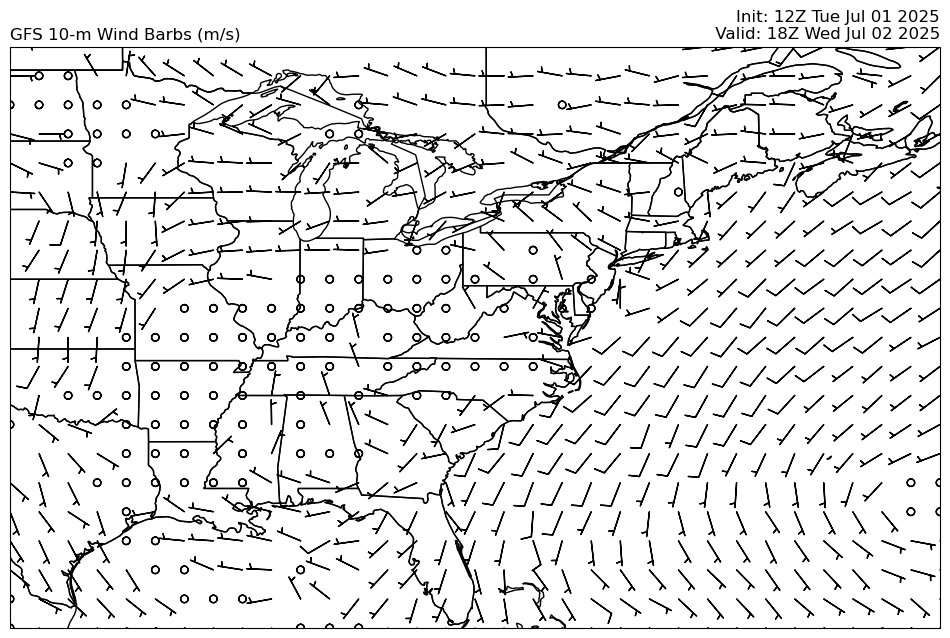

In [45]:
#Wind barb map
u_10 = ds_time['u10']
v_10 = ds_time['v10']
fig, ax = base_map()
skip = (slice(None, None, 5), slice(None, None, 5))
ax.barbs(ds_time['longitude'][skip[1]], ds_time['latitude'][skip[0]], u_10.values[skip], v_10.values[skip], length=6, color='black', transform=ccrs.PlateCarree())
init_time = pd.to_datetime(ds.valid_time.values[0]).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds_time.valid_time.values).strftime('%HZ %a %b %d %Y')
ax.set_title('GFS 10-m Wind Barbs (m/s)', loc='left', fontsize=12)
ax.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=12)